In [144]:
# basic imports
import pprint

import matplotlib.pylab as plt
import numpy as np

# tidy3d imports
import tidy3d as td

In [145]:
mm = 1e3  # millimeters

# patch antenna dimensions
patch_length = 30 * mm
patch_width = 30 * mm
patch_thickness = 0.02 * mm

# transmission line dimensions
transmission_width = 2 * mm
transmission_length = 90 * mm

# slot dimensions
slot_width = 5 * mm
slot_length = 3 * mm

# cutout dimensions
cutout_radius = 10 * mm

# substrate dimensions
sub_length = 50 * mm
sub_width = 50 * mm
sub_thickness = 1 * mm

In [146]:
# define patch geometry
patch_geometry_original = td.Box(
    center=(0, 0, 0),
    size=(patch_width, patch_length, patch_thickness),
)

tranmission_line_geometry = td.Box(
    center=(0, -transmission_length / 2, 0),
    size=(transmission_width, transmission_length, patch_thickness),
)

slot_geometry = td.Box(
    center=(0, -patch_length / 2 + slot_length / 2, 0),
    size=(slot_width, slot_length, patch_thickness),
)

cutout_geometry = td.Cylinder(
    center=(0, patch_length / 2, 0),
    axis=2,
    radius=cutout_radius,
    length=patch_thickness,
)

patch_geometry = (
    patch_geometry_original - slot_geometry + tranmission_line_geometry - cutout_geometry
)

# define ground plane geometry
ground_geometry = td.Box(
    center=(0, 0, -sub_thickness),
    size=(sub_width, sub_length, patch_thickness),
)

# define substrate geometry
sub_geometry = td.Box(
    center=(0, 0, -sub_thickness / 2),
    size=(sub_width, sub_length, sub_thickness),
)

In [147]:
patch = td.Structure(geometry=patch_geometry, medium=td.PEC)
ground = td.Structure(geometry=ground_geometry, medium=td.PEC)
substrate = td.Structure(geometry=sub_geometry, medium=td.Medium(permittivity=4.4))
structures = [substrate, patch, ground]

In [148]:
freq0 = 10e9  # 10 GHz
wavelength = td.C_0 / freq0
resolution = 10
grid_spec = td.GridSpec.auto(wavelength=wavelength, min_steps_per_wvl=resolution)

sim = td.Simulation(
    size=[60 * mm, 60 * mm, 20 * mm],
    grid_spec=grid_spec,
    structures=structures,
    run_time=td.RunTimeSpec(quality_factor=10),
    boundary_spec=td.BoundarySpec.pml(),
    plot_length_units="mm",
)

15:02:51 中国标准时间 WARNING: A structure has a nonzero dimension along axis z,
                      which is however too small compared to the generated mesh 
                      step along that direction. This could produce             
                      unpredictable results. We recommend increasing the        
                      resolution, or adding a mesh override structure to ensure 
                      that all geometries are at least one pixel thick along all
                      dimensions.                                               

                WARNING: Suppressed 2 WARNING messages.                         

In [149]:
# Plot simulation and overlay grid in the yz and xy planes
def plot_sim_grid(sim):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    sim.plot(z=0, ax=ax[0])
    sim.plot_grid(z=0, ax=ax[0])
    ax[0].set_xlim(-20 * mm, 20 * mm)
    ax[0].set_ylim(-20 * mm, 20 * mm)

    sim.plot(y=0, ax=ax[1])
    sim.plot_grid(y=0, ax=ax[1], override_structures_alpha=0)
    ax[1].set_xlim(-5 * mm, 5 * mm)
    ax[1].set_ylim(-5 * mm, 5 * mm)

    pprint.pp(sim.grid_info)

{'Nx': 41,
 'Ny': 41,
 'Nz': 7,
 'grid_points': 11767,
 'min_grid_size': 1428.5714285714275,
 'max_grid_size': 2996.666666666667,
 'computational_complexity': 8.236900000000006}


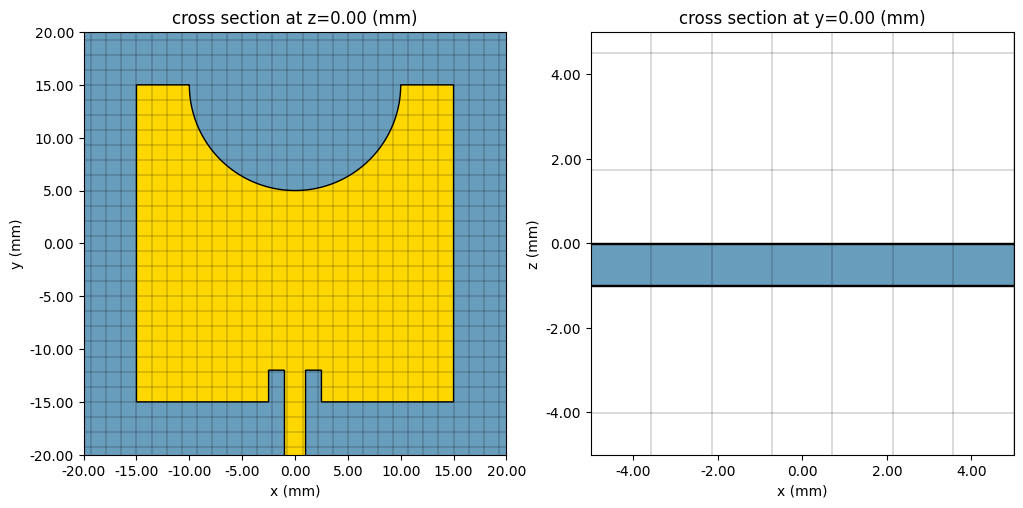

In [150]:
plot_sim_grid(sim)

In [151]:
# 3 ways of defining the layer
# 1) from class initialization
layer_spec = td.LayerRefinementSpec(
    axis=2,  # z-axis
    center=patch_geometry.bounding_box.center,
    size=(td.inf, td.inf, patch_thickness),
)
# 2) from layer bounds
layer_spec = td.LayerRefinementSpec.from_layer_bounds(
    axis=2,  # z-axis
    bounds=(-patch_thickness / 2, patch_thickness / 2),
)
# 3) from structures in the same layer
layer_spec = td.LayerRefinementSpec.from_structures(
    axis=2,
    structures=[patch],
)

                WARNING: A structure has a nonzero dimension along axis z, which
                is however too small compared to the generated mesh step along  
                that direction. This could produce unpredictable results. We    
                recommend increasing the resolution, or adding a mesh override  
                structure to ensure that all geometries are at least one pixel  
                thick along all dimensions.                                     

                WARNING: Suppressed 2 WARNING messages.                         

{'Nx': 46,
 'Ny': 43,
 'Nz': 11,
 'grid_points': 21758,
 'min_grid_size': 750.0,
 'max_grid_size': 2743.9997663497925,
 'computational_complexity': 29.010666666666665}


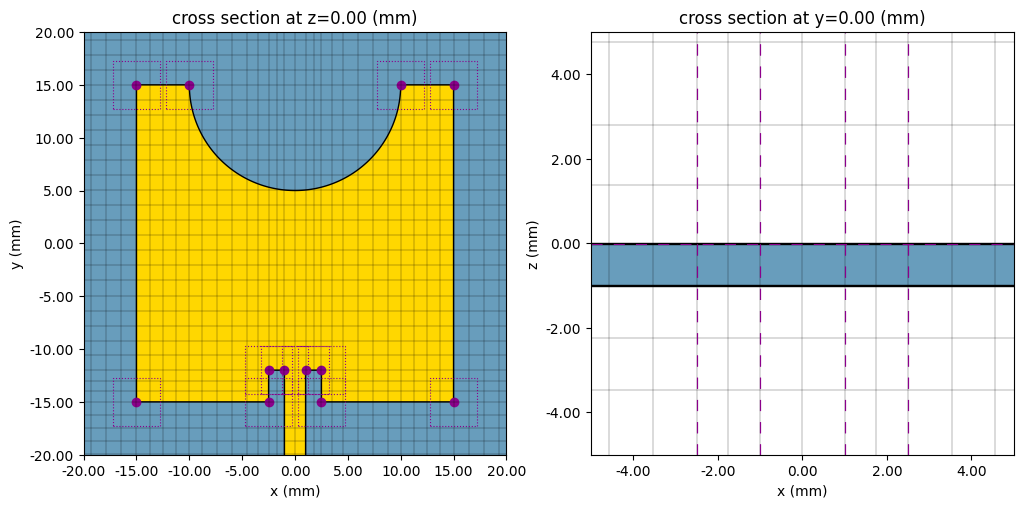

In [152]:
grid_spec_basic = grid_spec.updated_copy(layer_refinement_specs=[layer_spec])
sim_basic = sim.updated_copy(grid_spec=grid_spec_basic)

plot_sim_grid(sim_basic)

In [153]:
# approach 1: specify explicit grid size
corner_refinement = td.GridRefinement(dl=0.5 * mm)

# approach 2: specify refinement factor
grid_size_in_vacuum = wavelength / resolution
corner_refinement = td.GridRefinement(refinement_factor=grid_size_in_vacuum / (0.5 * mm))

# define layer refinement spec
layer_spec = td.LayerRefinementSpec.from_structures(
    axis=2,
    structures=[patch],
    corner_refinement=corner_refinement,
)

15:02:52 中国标准时间 WARNING: A structure has a nonzero dimension along axis z,
                      which is however too small compared to the generated mesh 
                      step along that direction. This could produce             
                      unpredictable results. We recommend increasing the        
                      resolution, or adding a mesh override structure to ensure 
                      that all geometries are at least one pixel thick along all
                      dimensions.                                               

                WARNING: Suppressed 2 WARNING messages.                         

{'Nx': 83,
 'Ny': 59,
 'Nz': 11,
 'grid_points': 53867,
 'min_grid_size': 374.9999999999982,
 'max_grid_size': 2743.9997663497925,
 'computational_complexity': 143.64533333333404}


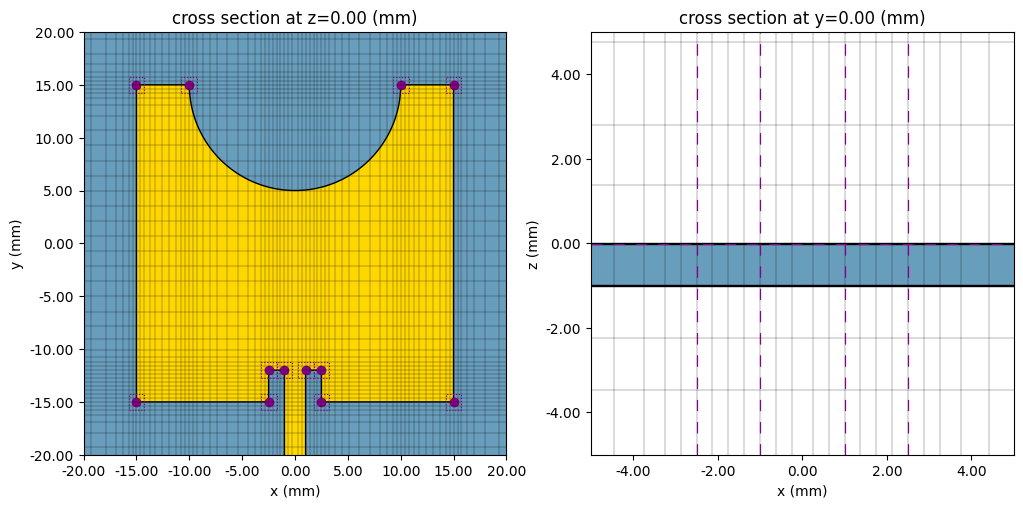

In [154]:
grid_spec_finer = grid_spec.updated_copy(layer_refinement_specs=[layer_spec])
sim_finer = sim.updated_copy(grid_spec=grid_spec_finer)

plot_sim_grid(sim_finer)

15:04:41 中国标准时间 WARNING: A structure has a nonzero dimension along axis z,
                      which is however too small compared to the generated mesh 
                      step along that direction. This could produce             
                      unpredictable results. We recommend increasing the        
                      resolution, or adding a mesh override structure to ensure 
                      that all geometries are at least one pixel thick along all
                      dimensions.                                               

                WARNING: Suppressed 1 WARNING message.                          

{'Nx': 83,
 'Ny': 59,
 'Nz': 17,
 'grid_points': 83249,
 'min_grid_size': 374.9999999999982,
 'max_grid_size': 2000.886252686876,
 'computational_complexity': 221.9973333333344}


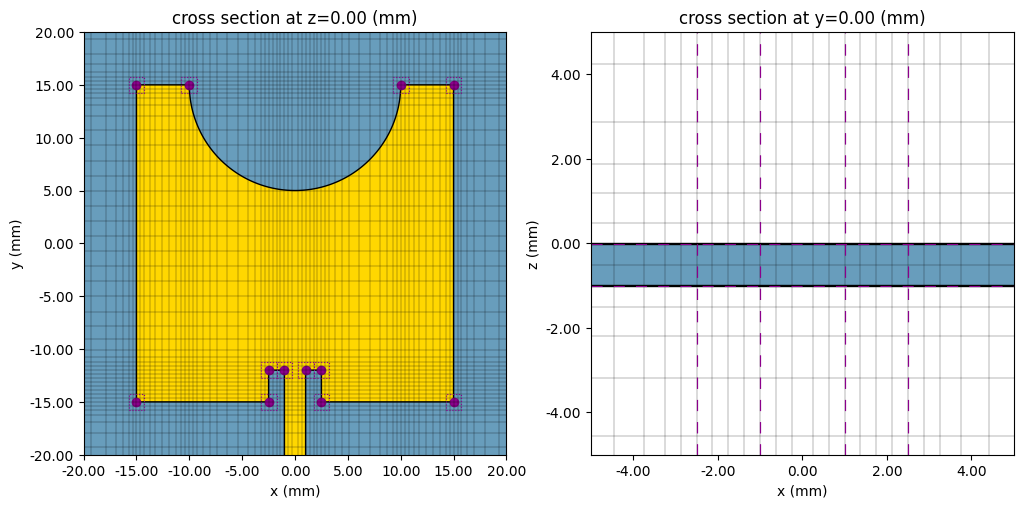

In [155]:
# define layer refinement spec for substrate layer
subs_layer_spec = td.LayerRefinementSpec.from_structures(
    axis=2,
    structures=[substrate],
    corner_finder=None,
    min_steps_along_axis=2,
)

grid_spec_subs = grid_spec.updated_copy(layer_refinement_specs=[subs_layer_spec, layer_spec])
sim_subs = sim.updated_copy(grid_spec=grid_spec_subs)

plot_sim_grid(sim_subs)